# 🔍 Εργαστήριο Process Mining (Εξόρυξη Διεργασιών)

Σε αυτό το εργαστήριο θα ανακαλύψουμε αυτόματα το μοντέλο μιας επιχειρησιακής διεργασίας (BPMN / Process Map) από τα ψηφιακά ίχνη (Event Log) ενός e-shop, εντοπίζοντας πού υπάρχουν καθυστερήσεις (bottlenecks)!

In [1]:
# Εγκατάσταση απαραίτητων βιβλιοθηκών
!pip install -q pm4py pandas numpy matplotlib graphviz


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## 📥 Βήμα 1: Δημιουργία Συνθετικού Event Log

Κανονικά, τα δεδομένα αυτά τα παίρνουμε από το ERP της εταιρείας (π.χ. SAP). Εδώ θα γράψουμε ένα script που γεννά **1000 παραγγελίες**, εισάγοντας επίτηδες καθυστερήσεις στην Αποθήκη και σφάλματα συσκευασίας («λούπες» / rework).

In [2]:
import pandas as pd
import random
from datetime import datetime, timedelta

# Παραγωγή δεδομένων
data = []
case_id = 1
start_time = datetime(2024, 1, 1, 8, 0, 0)

for i in range(1000):
    current_time = start_time + timedelta(minutes=random.randint(1, 60))
    
    # 1. Υποβολή
    data.append([case_id, "Υποβολή Παραγγελίας", current_time, "Πελάτης"])
    
    # 2. Έλεγχος Πληρωμής
    current_time += timedelta(minutes=random.randint(1, 15))
    data.append([case_id, "Έλεγχος Πληρωμής", current_time, "Σύστημα"])
    
    if random.random() < 0.1: # 10% αποτυχία πληρωμής
        current_time += timedelta(minutes=random.randint(10, 60))
        data.append([case_id, "Ακύρωση Παραγγελίας", current_time, "Σύστημα"])
    else:
        # 3. Συλλογή (Picking) - BOTTLE NECK: Μεγάλη καθυστέρηση!
        current_time += timedelta(hours=random.randint(2, 24))
        data.append([case_id, "Συλλογή Προϊόντων", current_time, "Αποθηκάριος"])
        
        # 4. Συσκευασία
        current_time += timedelta(minutes=random.randint(10, 30))
        data.append([case_id, "Συσκευασία", current_time, "Αποθηκάριος"])
        
        # 5. Λάθος Συσκευασίας - REWORK
        if random.random() < 0.15: # 15% πιθανότητα λάθους
            current_time += timedelta(minutes=random.randint(15, 60))
            data.append([case_id, "Διόρθωση Συσκευασίας", current_time, "Επόπτης"])
            current_time += timedelta(minutes=random.randint(5, 15))
            data.append([case_id, "Συσκευασία", current_time, "Αποθηκάριος"])
        
        # 6. Αποστολή
        current_time += timedelta(hours=random.randint(1, 5))
        data.append([case_id, "Αποστολή", current_time, "Courier"])
        
    case_id += 1
    start_time += timedelta(minutes=random.randint(5, 20))

# Αποθήκευση σε DataFrame και CSV
df = pd.DataFrame(data, columns=["CaseID", "Activity", "Timestamp", "Resource"])
df.to_csv("eshop_event_log.csv", index=False)
print(f"Δημιουργήθηκαν {len(df)} γεγονότα (events) για {case_id-1} παραγγελίες (cases).")
df.head()

Δημιουργήθηκαν 5042 γεγονότα (events) για 1000 παραγγελίες (cases).


,CaseID,Activity,Timestamp,Resource
0,1,Υποβολή Παραγγελίας,2024-01-01 08:07:00,Πελάτης
1,1,Έλεγχος Πληρωμής,2024-01-01 08:18:00,Σύστημα
2,1,Συλλογή Προϊόντων,2024-01-02 01:18:00,Αποθηκάριος
3,1,Συσκευασία,2024-01-02 01:38:00,Αποθηκάριος
4,1,Αποστολή,2024-01-02 03:38:00,Courier


## 📂 Βήμα 2: Φόρτωση Event Log στο PM4Py

Διαβάζουμε το CSV και το μετατρέπουμε στη μορφή που καταλαβαίνει η βιβλιοθήκη PM4Py.

In [3]:
import pm4py

# Διάβασμα δεδομένων
dataframe = pd.read_csv('eshop_event_log.csv')

# Μετατροπή της στήλης Timestamp σε μορφή ημερομηνίας
dataframe['Timestamp'] = pd.to_datetime(dataframe['Timestamp'])

# Δήλωση των στηλών-κλειδιών στο pm4py
event_log = pm4py.format_dataframe(dataframe, case_id='CaseID', activity_key='Activity', timestamp_key='Timestamp')
print("Το Event Log φορτώθηκε επιτυχώς!")

Το Event Log φορτώθηκε επιτυχώς!


## 🔮 Βήμα 3: Ανακάλυψη Διεργασίας (Process Discovery - Frequency)

Αρχικά θα εξάγουμε τον χάρτη της διεργασίας (**Process Map** ή DFG - Directly-Follows Graph) με βάση τη **συχνότητα** των γεγονότων. Πού πάνε οι περισσότερες παραγγελίες;

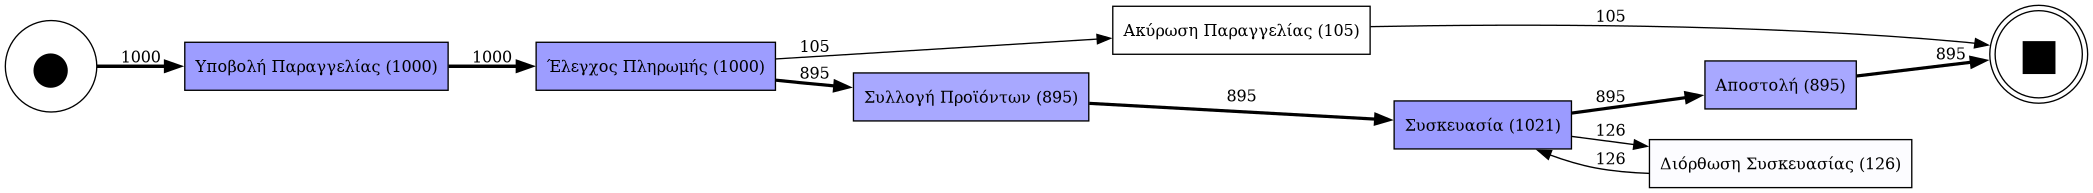

In [4]:
# Δημιουργία χάρτη συχνοτήτων
dfg, start_activities, end_activities = pm4py.discover_dfg(event_log)

# Οπτικοποίηση
pm4py.view_dfg(dfg, start_activities, end_activities)

## ⏱️ Βήμα 4: Ανάλυση Απόδοσης (Εντοπισμός Bottleneck)

Εδώ είναι η πραγματική αξία του Process Mining! Αντί για τον αριθμό των περιστατικών, θα προβάλουμε τον **μέσο χρόνο αναμονής (Average Time)** πάνω στα βέλη.

*Παρατηρήστε το κόκκινο βέλος (Bottleneck) μεταξύ «Έλεγχος Πληρωμής» και «Συλλογή Προϊόντων».*

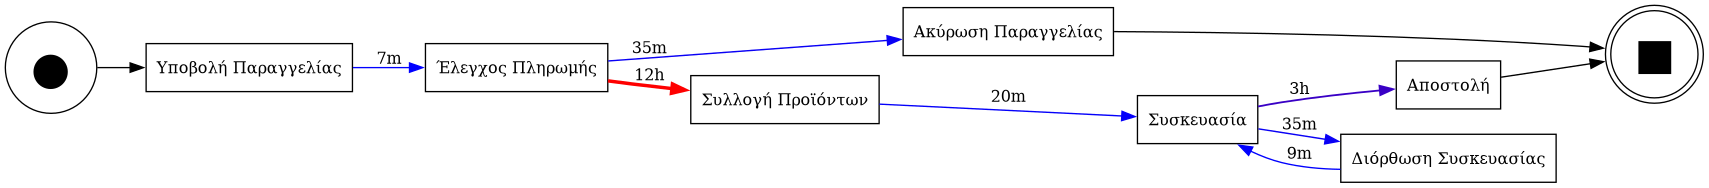

In [5]:
# Δημιουργία χάρτη απόδοσης (Performance Map)
dfg_perf, start_activities_perf, end_activities_perf = pm4py.discover_performance_dfg(event_log)

# Οπτικοποίηση
pm4py.view_performance_dfg(dfg_perf, start_activities_perf, end_activities_perf)

## ⚙️ Βήμα 5: Εξαγωγή σε BPMN Μοντέλο

Τέλος, μπορούμε να μετατρέψουμε τον παραπάνω γράφο σε αυστηρό, τυποποιημένο διάγραμμα **BPMN 2.0** χρησιμοποιώντας τον Inductive Miner. Αυτό το μοντέλο μπορεί να εξαχθεί και να ανοίξει στο Signavio ή την Camunda!

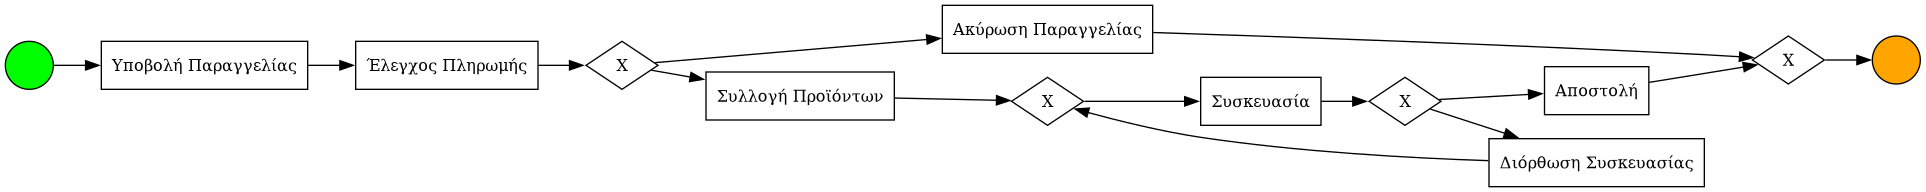

In [6]:
# Ανακάλυψη BPMN μοντέλου χρησιμοποιώντας τον Inductive Miner
bpmn_model = pm4py.discover_bpmn_inductive(event_log)

# Οπτικοποίηση
pm4py.view_bpmn(bpmn_model)

## 📤 Βήμα 6: Εξαγωγή του Μοντέλου για το Signavio

Το μοντέλο BPMN που ανακαλύψαμε στο **Βήμα 5** μπορεί να εξαχθεί σε ένα αρχείο `.bpmn` και στη συνέχεια να εισαχθεί στο SAP Signavio (ή σε οποιοδήποτε άλλο εργαλείο μοντελοποίησης) για περαιτέρω ανάλυση, προσομοίωση ή βελτίωση.

Για να το κάνουμε αυτό, προσθέτουμε την παρακάτω εντολή στο τέλος του κώδικα:

In [7]:
# Εξαγωγή του μοντέλου σε αρχείο BPMN 2.0 (XML)
pm4py.write_bpmn(bpmn_model, "discovered_process.bpmn")

print("Το μοντέλο αποθηκεύτηκε ως 'discovered_process.bpmn'.")

# Τώρα μπορείτε να κατεβάσετε αυτό το αρχείο από το μενού 'Αρχεία' του Colab και να το κάνετε import στο Signavio.

Το μοντέλο αποθηκεύτηκε ως 'discovered_process.bpmn'.
